# 📏 Model Calibration — Reliability Diagram
**World Cup 2026 Predictor** · A model can be *accurate* and still *lie* about its confidence.
Calibration asks a different question: **when the model says 70%, does it actually happen ~70% of the time?**

A well-calibrated forecaster is trustworthy: its probabilities mean what they say. This is the
property that separates a serious probabilistic model from one that just outputs numbers. We measure
it with a **reliability diagram** and the **Expected Calibration Error (ECE)**.

## 1. Collect predictions vs outcomes (leave-one-tournament-out)
Same honest setup as notebook 06: for each World Cup 1998-2022 we train the v1 model on prior data
and record its probabilities on that tournament's matches — predictions the model never trained on.

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier

HEIR = {"West Germany": "Germany", "Soviet Union": "Russia", "Yugoslavia": "Serbia",
        "Serbia and Montenegro": "Serbia", "Czechoslovakia": "Czech Republic",
        "Zaire": "DR Congo", "Dutch East Indies": "Indonesia"}

matches = pd.read_csv("../data/raw/historical/matches.csv")
m = matches[matches["tournament_name"].str.contains("Men's")].copy()
m["year"] = m["tournament_name"].str[:4].astype(int)
m["match_date"] = pd.to_datetime(m["match_date"])
m["home_team_name"] = m["home_team_name"].replace(HEIR)
m["away_team_name"] = m["away_team_name"].replace(HEIR)

intl = pd.read_csv("../data/processed/internationals_with_elo.csv")
intl["date"] = pd.to_datetime(intl["date"])
ec = intl[["date", "home_team", "away_team", "elo_home_pre", "elo_away_pre"]]
merged = m.merge(ec, left_on=["match_date", "home_team_name", "away_team_name"],
                 right_on=["date", "home_team", "away_team"], how="left")
swapped = m.merge(ec, left_on=["match_date", "home_team_name", "away_team_name"],
                  right_on=["date", "away_team", "home_team"], how="left")
merged["elo_home_pre"] = merged["elo_home_pre"].fillna(swapped["elo_away_pre"])
merged["elo_away_pre"] = merged["elo_away_pre"].fillna(swapped["elo_home_pre"])

home = m[["year", "home_team_name", "home_team_score", "away_team_score", "home_team_win", "draw"]].copy()
home.columns = ["year", "team", "gf", "ga", "won", "draw"]
away = m[["year", "away_team_name", "away_team_score", "home_team_score", "away_team_win", "draw"]].copy()
away.columns = ["year", "team", "gf", "ga", "won", "draw"]
tm = pd.concat([home, away], ignore_index=True)

def feats(team, year, pre):
    past = tm[(tm["team"] == team) & (tm["year"] < year)]
    if len(past) == 0:
        return {f"{pre}_wc_played": 0, f"{pre}_win_rate": 0.0, f"{pre}_goals_for": 0.0,
                f"{pre}_goals_against": 0.0, f"{pre}_recent_form": 0.0}
    last_two = sorted(past["year"].unique())[-2:]
    rec = past[past["year"].isin(last_two)]
    return {f"{pre}_wc_played": past["year"].nunique(), f"{pre}_win_rate": past["won"].mean(),
            f"{pre}_goals_for": past["gf"].mean(), f"{pre}_goals_against": past["ga"].mean(),
            f"{pre}_recent_form": rec["won"].mean()}

tnm = pd.read_csv("../data/raw/historical/tournaments.csv")
tnm = tnm[tnm["tournament_name"].str.contains("Men's")].copy()
tnm["year"] = tnm["tournament_name"].str[:4].astype(int)
host_by_year = tnm.set_index("year")["host_country"].to_dict()

rows = []
for _, x in merged[(merged["year"] >= 1962) & (merged["group_stage"] == 1) & (merged["elo_home_pre"].notna())].iterrows():
    r = {"year": x["year"]}
    r.update(feats(x["home_team_name"], x["year"], "home"))
    r.update(feats(x["away_team_name"], x["year"], "away"))
    host = host_by_year.get(x["year"], "")
    r["home_is_host"] = int(x["home_team_name"] == host); r["away_is_host"] = int(x["away_team_name"] == host)
    r["elo_home"] = x["elo_home_pre"]; r["elo_away"] = x["elo_away_pre"]; r["elo_diff"] = x["elo_home_pre"] - x["elo_away_pre"]
    r["target"] = 0 if x["home_team_win"] == 1 else (1 if x["draw"] == 1 else 2)
    rows.append(r)
data = pd.DataFrame(rows)
data["diff_win_rate"] = data["home_win_rate"] - data["away_win_rate"]
data["diff_form"] = data["home_recent_form"] - data["away_recent_form"]

FEATURES = ["home_wc_played", "home_win_rate", "home_goals_for", "home_goals_against",
            "home_recent_form", "home_is_host", "away_wc_played", "away_win_rate",
            "away_goals_for", "away_goals_against", "away_recent_form", "away_is_host",
            "diff_win_rate", "diff_form", "elo_home", "elo_away", "elo_diff"]

# Collect (predicted probability, outcome happened?) for every class on every test match
probs, hits = [], []
for ty in sorted(data["year"].unique()):
    if ty < 1998:
        continue
    tr, te = data[data["year"] < ty], data[data["year"] == ty]
    rf = RandomForestClassifier(n_estimators=300, max_depth=6, random_state=42).fit(tr[FEATURES], tr["target"])
    pp = rf.predict_proba(te[FEATURES])
    for (_, row), pr in zip(te.iterrows(), pp):
        for cls in range(3):
            probs.append(pr[cls]); hits.append(int(row["target"] == cls))
probs, hits = np.array(probs), np.array(hits)
print(f"Collected {len(probs)} (probability, outcome) pairs from {data[data['year']>=1998]['year'].nunique()} World Cups")

Collected 1008 (probability, outcome) pairs from 7 World Cups


## 2. The reliability diagram
We bin predictions by confidence (0-10%, 10-20%, ...). For each bin we plot the **mean predicted
probability** (x) against the **actual frequency** the event happened (y). Perfect calibration is the
diagonal: predictions land exactly on the line.

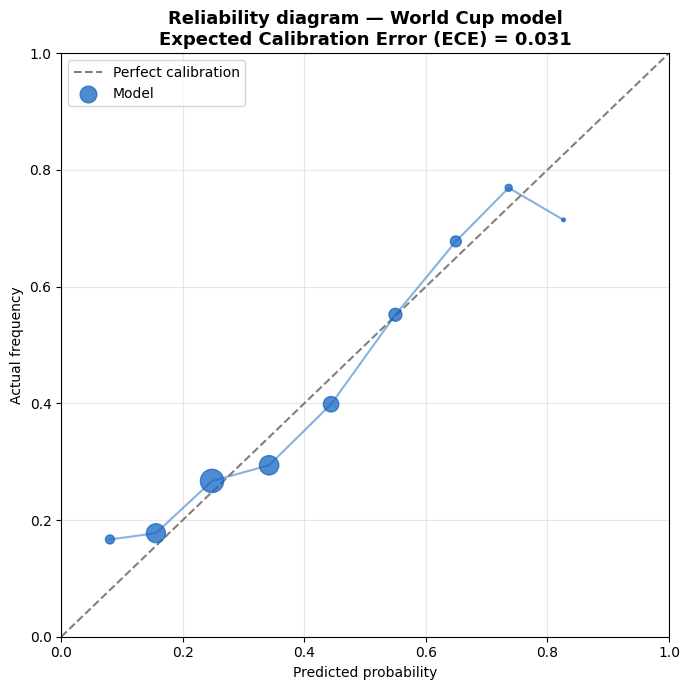

ECE = 0.031  (0 = perfect; below ~0.05 is well calibrated)


In [2]:
bins = np.linspace(0, 1, 11)
idx = np.digitize(probs, bins) - 1
xs, ys, sizes, ece = [], [], [], 0.0
for b in range(10):
    mask = idx == b
    if mask.sum() < 5:
        continue
    conf, freq = probs[mask].mean(), hits[mask].mean()
    xs.append(conf); ys.append(freq); sizes.append(mask.sum())
    ece += mask.sum() / len(probs) * abs(conf - freq)

fig, ax = plt.subplots(figsize=(7, 7))
ax.plot([0, 1], [0, 1], "--", color="gray", label="Perfect calibration")
ax.scatter(xs, ys, s=[min(s, 400) for s in sizes], color="#1565C0", alpha=0.75, zorder=3, label="Model")
ax.plot(xs, ys, color="#1565C0", alpha=0.5, zorder=2)
ax.set_xlabel("Predicted probability"); ax.set_ylabel("Actual frequency")
ax.set_title(f"Reliability diagram — World Cup model\nExpected Calibration Error (ECE) = {ece:.3f}",
             fontsize=13, fontweight="bold")
ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("../data/processed/calibration.png", dpi=180, bbox_inches="tight", facecolor="white")
plt.show()
print(f"ECE = {ece:.3f}  (0 = perfect; below ~0.05 is well calibrated)")

## 3. Reading the diagram

- **On the diagonal = honest probabilities.** When the model says 30%, it happens ~30% of the time.
- **Points above the line** = the model is *under-confident* (events happen more than it predicts);
  **below the line** = *over-confident*.
- **ECE (Expected Calibration Error)** summarises the average gap. Below ~0.05 is considered well
  calibrated — meaning the percentages on the dashboard can be trusted as real probabilities, not
  just relative rankings.

**Why it matters:** a model can have mediocre accuracy yet be perfectly calibrated — and a calibrated
70% really means "7 times out of 10". That trustworthiness is what lets the Monte Carlo simulator and
the title odds mean something. Reporting calibration (not just accuracy) is standard practice for
serious probabilistic forecasting.